# 10v5_02 — Training-scale comparison + spectrum-model freeze

Only the **training population** changes: V1_RND_1K, V1_TL_1K, V1_TL_3K and V1_TL_10K all use the
exact v4b V1 recipe. That means the same 9 features in the same order, `LGBM_PARAMS`,
lambdarank, seed 42, one group per query, 5 connectivity folds and mirror_aware evidence.
There is no tuning and no new feature.

**Fair comparison.** Every model scores the **same** TL_EVAL and HOST queries with the **mean of
its 5 fold models**. OOF numbers on each model's own training population are kept as training
diagnostics only.

**Order.** The pre-registered rules (`casmi.ranking.scaling.V5_RULE`) are written first. The
TL-EVAL results, the scale decision and the headline model are then **locked** before any
HOST metric is computed. HOST confirms and cannot switch the model.

The notebook runs with whatever scale manifests are built. TL_1K alone proves the pipeline;
re-run it after the TL_3K and TL_10K builds. The rules apply to the largest available nested
pair.

In [1]:
import sys, json, time, hashlib, inspect
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.candidates.generator import CandidateGenerator, dedupe_pool_to_connectivity
from casmi.candidates.mass_index import MassIndex
from casmi.qcr.aggregate import aggregate_deterministic
from casmi.qcr.context import HOST_INGEST_LIB, SEED, config_hash, v4b_paths, v5_paths
from casmi.qcr.fingerprint import code_version
from casmi.qcr.settlement import load_settlement_or_refuse
from casmi.ranking.baselines import b1, fusion
from casmi.ranking.lambdamart import BASE_FEATURES, LGBM_PARAMS, fit_fold_models, load_fold_models, predict_by_fold, save_fold_models
from casmi.ranking.manifests import load_manifest
from casmi.ranking.mass_likelihood import MassLikelihoodModel
from casmi.ranking.rank_eval import per_query_metrics, rank_by_keys, summarize
from casmi.ranking.scaling import (
    HEADLINE_CANDIDATES, MODEL_MANIFEST, PAIRED_COMPARISONS, POOL_BIN_EDGES, SCALE_MODELS, V5_RULE, density_reweighted_mrr,
    pool_size_stratification, scale_decision, score_population, select_scale_headline,
)
from casmi.ranking.selection import DevSelectionLock, lock_dev_selection, require_dev_selection_lock, write_preregistration
from casmi.validation.cluster_bootstrap import cluster_bootstrap_mean, paired_comparison_row
from casmi.validation.decision_log import log_decision

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
PREREG = D['freeze'] / 'preregistration_v5.json'
N_BOOT, K_STRESS = 2000, (1, 3, 5)
KEY = 'candidate_connectivity_key'
RESULTS = {'tl_eval': {}, 'host': {}, 'oof': {}}


def jdump(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding='utf-8')


def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

## 0. Preconditions + pre-registration (written before any metric)

In [2]:
settlement = load_settlement_or_refuse(vp.settlement_json)
ARTS = settlement['evidence_artifacts']
SIM_HASH = config_hash(settlement['similarity_config'])
PARAMS_HASH = hashlib.sha256(json.dumps(LGBM_PARAMS, sort_keys=True).encode()).hexdigest()[:16]
prereg = write_preregistration(PREREG, rule=V5_RULE, extra={'lgbm_params': LGBM_PARAMS, 'features': BASE_FEATURES, 'seed': SEED,
                                                            'n_boot': N_BOOT, 'pool_bin_edges': [str(e) for e in POOL_BIN_EDGES]})
print('cache decision:', settlement['decision'], '| v5 rule sha256:', prereg['rule_sha256'])
log_decision(decision='v5 scale-decision + headline rules pre-registered', evidence_used=f"sha256 {prereg['rule_sha256']}",
             host_visible=False, category='pre_registered_choice', log_path=paths.outputs / 'decision_log.jsonl')

cache decision: REBUILT_AND_VALIDATED | v5 rule sha256: 639e0ac606781c4dd47171bcc364a7a07cc2ac6aa3ee9dd4b6e3a426670d5da9


{'timestamp': '2026-09-25T15:26:03.185220+00:00',
 'decision': 'v5 scale-decision + headline rules pre-registered',
 'evidence_used': 'sha256 639e0ac606781c4dd47171bcc364a7a07cc2ac6aa3ee9dd4b6e3a426670d5da9',
 'host_visible': False,
 'category': 'pre_registered_choice'}

## 1. Manifests + persisted features (TL_EVAL required; training sets as available)

In [3]:
MAN, MAN_META, FEATS = {}, {}, {}
for n in ('TL_EVAL', 'TL_1K', 'TL_3K', 'TL_10K', 'RND_1K'):
    if not (D['manifests'] / f'{n}.parquet').exists():
        continue
    MAN[n], MAN_META[n] = load_manifest(n, D['manifests'])          # verifies content sha256
    fp, bp = D['features'] / f'{n}_mirror_aware.parquet', D['features'] / f'{n}_mirror_aware.build.json'
    if fp.exists() and bp.exists():
        build = json.loads(bp.read_text(encoding='utf-8'))
        assert build['manifest_sha256'] == MAN_META[n]['manifest_sha256'], f'{n}: features built from a different manifest'
        assert build['evidence_fingerprint'] == settlement['evidence_fingerprint'], f'{n}: features built on different evidence'
        FEATS[n] = pd.read_parquet(fp)
assert 'TL_EVAL' in FEATS, 'build TL_EVAL features first (scripts/v5_build_scale_features.py --manifest TL_EVAL)'
TL_IDS = MAN['TL_EVAL']['query_id'].tolist()
CLUSTER_TL = MAN['TL_EVAL'].set_index('query_id')['connectivity_key'].to_dict()

host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet')
HOST_IDS = host_q['query_id'].tolist()
CLUSTER_HOST = host_q.set_index('query_id')['true_connectivity_key'].to_dict()
host_meta = host_q[['query_id', 'fold', 'true_connectivity_key', 'instrument_type', 'adduct']].rename(columns={'instrument_type': 'instrument'})
HOSTF = pd.read_parquet(ARTS['host_features_mirror_aware']).drop(columns=['fold'], errors='ignore').merge(host_meta, on='query_id', how='left')

TL_KEYS, HOST_KEYS = set(MAN['TL_EVAL']['connectivity_key']), set(host_q['true_connectivity_key'])
leak = {n: {'tl_eval': len(set(m['connectivity_key']) & TL_KEYS), 'host': len(set(m['connectivity_key']) & HOST_KEYS)}
        for n, m in MAN.items() if n != 'TL_EVAL'}
print('training-manifest structure overlap with TL_EVAL / HOST (must all be 0):', leak)
assert all(v == 0 for d in leak.values() for v in d.values())
assert not (TL_KEYS & HOST_KEYS)
display(pd.DataFrame({n: {'queries': len(MAN[n]), 'features_built': n in FEATS} for n in MAN}).T)

training-manifest structure overlap with TL_EVAL / HOST (must all be 0): {'TL_1K': {'tl_eval': 0, 'host': 0}, 'TL_3K': {'tl_eval': 0, 'host': 0}, 'TL_10K': {'tl_eval': 0, 'host': 0}, 'RND_1K': {'tl_eval': 0, 'host': 0}}


,queries,features_built
TL_EVAL,1000,True
TL_1K,1000,True
TL_3K,3000,False
TL_10K,10000,False
RND_1K,1000,True


## 2. Train the scale models: exact V1 recipe, 5 fold boosters each

In [4]:
MODELS, STATUS, N_TRAIN = {}, {}, {}
CODE_VERSION = code_version()
for mid in SCALE_MODELS:
    man = MODEL_MANIFEST[mid]
    if man not in FEATS:
        STATUS[mid] = 'NOT_RUN'
        continue
    tr = FEATS[man]
    folds = sorted(tr['fold'].unique())
    assert len(folds) == 5, f'{mid}: expected 5 connectivity folds, got {folds}'
    models, audit = fit_fold_models(tr, BASE_FEATURES, fold_col='fold', folds=folds, params=LGBM_PARAMS)
    fold_manifest = [{'fold': int(f), 'n_train_queries': int(tr.loc[tr.fold != f, 'query_id'].nunique()),
                      'n_heldout_queries': int(tr.loc[tr.fold == f, 'query_id'].nunique()),
                      'heldout_query_ids_sha256': hashlib.sha256('\n'.join(sorted(tr.loc[tr.fold == f, 'query_id'].unique())).encode()).hexdigest()}
                     for f in folds]
    out = D['models'] / mid
    save_fold_models(models, out, BASE_FEATURES, LGBM_PARAMS, tr['query_id'].unique(), extra={
        'model_id': mid, 'training_manifest': man, 'training_manifest_hash': MAN_META[man]['manifest_sha256'],
        'similarity_config_hash': SIM_HASH, 'lgbm_params_hash': PARAMS_HASH,
        'config_hash': hashlib.sha256(f'{SIM_HASH}|{PARAMS_HASH}|{BASE_FEATURES}'.encode()).hexdigest()[:16],
        'seed': SEED, 'code_version': CODE_VERSION, 'fold_manifest': fold_manifest, 'evidence_fingerprint': settlement['evidence_fingerprint'],
        'recipe': 'v4b V1 (BASE_FEATURES, LGBM_PARAMS, lambdarank, one group per query, 5 connectivity folds, mirror_aware)'})
    jdump(BASE_FEATURES, out / 'feature_names.json')
    # training diagnostic only: OOF on the model's OWN population (never used for the scale comparison)
    oof = tr[['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate', 'fold']].assign(score=predict_by_fold(models, tr, BASE_FEATURES).to_numpy())
    oof.to_parquet(out / 'oof_rows.parquet', index=False)
    RESULTS['oof'][mid] = summarize(per_query_metrics(rank_by_keys(oof, [('score', False), ('abs_mass_error_ppm', True), (KEY, True)]),
                                                      MAN[man]['query_id'].tolist()))
    MODELS[mid], STATUS[mid], N_TRAIN[mid] = models, 'OK', int(len(MAN[man]))
    print(f'{mid}: {N_TRAIN[mid]:,} training queries | own-population OOF MRR@25 (diagnostic) = {RESULTS["oof"][mid]["mrr_at_25"]:.4f}')
print('status:', STATUS)

V1_RND_1K: 1,000 training queries | own-population OOF MRR@25 (diagnostic) = 0.4244
V1_TL_1K: 1,000 training queries | own-population OOF MRR@25 (diagnostic) = 0.1560
status: {'V1_RND_1K': 'OK', 'V1_TL_1K': 'OK', 'V1_TL_3K': 'NOT_RUN', 'V1_TL_10K': 'NOT_RUN'}


# SELECTION PHASE: TL_EVAL only

## 3. Common-population scoring on TL_EVAL (fold-mean), frozen B5, context baselines

**B5 separation.** The alpha and the z-standardizer were chosen on DEV-1k in v4b (the persisted
`outputs/v4b/dev_selection_lock.json`). The mass-likelihood model is the frozen v4b fit
(`outputs/v4b/metrics/mass_likelihood_model.json`). TL_EVAL excludes every DEV-1k structure and
every spectrum that fit used, so nothing is refit on or tuned to TL_EVAL.

**Historical V1 (v4b, DEV-1k-trained)** is shown as a reference row. It is not a candidate.

In [5]:
TL = FEATS['TL_EVAL']
TL_PQ, TL_RANKED = {}, {}
for mid, models in MODELS.items():
    TL_PQ[mid], TL_RANKED[mid] = score_population(models, TL, BASE_FEATURES, TL_IDS)

v4b_lock = json.loads((vp.out / 'dev_selection_lock.json').read_text(encoding='utf-8'))
B5_ALPHA, B5_STD = float(v4b_lock['alphas']['B5']), v4b_lock['dev_standardizer']
mass_model = MassLikelihoodModel.from_dict(json.loads((vp.out / 'metrics' / 'mass_likelihood_model.json').read_text(encoding='utf-8')))


def with_mass_loglik(df):
    d = df.rename(columns={'instrument': 'instrument_type'})
    ll, _ = mass_model.loglik(d)
    return d.assign(mass_loglik=ll)


TL_B = with_mass_loglik(TL)
TL_PQ['B5_frozen_v4b'] = fusion(TL_B, TL_IDS, 'modified_cosine_max', B5_ALPHA, B5_STD)
TL_PQ['B1_mass'] = b1(TL_B, TL_IDS)
v1_hist, _ = load_fold_models(vp.out / 'models' / 'V1')
TL_PQ['V1_v4b_DEV1k_reference'], _ = score_population(v1_hist, TL, BASE_FEATURES, TL_IDS)
for m, pq in TL_PQ.items():
    RESULTS['tl_eval'][m] = summarize(pq)
    pq.to_parquet(D['metrics'] / f'tl_eval_per_query_{m}.parquet', index=False)
tl_table = pd.DataFrame([{'model': m, 'n_train_queries': N_TRAIN.get(m), **RESULTS['tl_eval'][m]} for m in TL_PQ])
display(tl_table)

,model,n_train_queries,n_queries,n_with_candidates,mrr_at_25,hit_at_1,hit_at_5,hit_at_25
0,V1_RND_1K,1000.0,1000,1000,0.183634,0.090,0.273,0.641
1,V1_TL_1K,1000.0,1000,1000,0.186641,0.093,0.272,0.656
2,B5_frozen_v4b,NaN,1000,1000,0.127449,0.046,0.199,0.564
3,B1_mass,NaN,1000,1000,0.141757,0.058,0.214,0.596
4,V1_v4b_DEV1k_reference,NaN,1000,1000,0.181566,0.089,0.272,0.641


## 4. TL_EVAL connectivity bootstrap. Paired deltas share the same cluster draws.

In [6]:
tl_ci = pd.DataFrame([{'model': m, **cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_TL).to_numpy(), n_boot=N_BOOT, seed=SEED)}
                      for m, pq in TL_PQ.items()])
pairs = [p for p in PAIRED_COMPARISONS if p[0] in TL_PQ and p[1] in TL_PQ]
pairs += [(m, 'B5_frozen_v4b') for m in HEADLINE_CANDIDATES if m in TL_PQ]
tl_boot = pd.DataFrame([paired_comparison_row(a, TL_PQ[a], b, TL_PQ[b], CLUSTER_TL, n_boot=N_BOOT, seed=SEED) for a, b in pairs])
tl_ci.to_parquet(D['bootstrap'] / 'tl_eval_mrr_ci.parquet', index=False)
tl_boot.to_parquet(D['bootstrap'] / 'tl_eval_paired.parquet', index=False)
display(tl_ci[['model', 'mean', 'ci_low', 'ci_high', 'n_queries', 'n_clusters']])
display(tl_boot[['comparison', 'mean_a', 'mean_b', 'delta', 'ci_low', 'ci_high', 'excludes_zero', 'n_clusters']])

,model,mean,ci_low,ci_high,n_queries,n_clusters
0,V1_RND_1K,0.183634,0.165755,0.201094,1000,1000
1,V1_TL_1K,0.186641,0.168536,0.204503,1000,1000
2,B5_frozen_v4b,0.127449,0.113933,0.142180,1000,1000
3,B1_mass,0.141757,0.127374,0.156485,1000,1000
4,V1_v4b_DEV1k_reference,0.181566,0.164391,0.198988,1000,1000


,comparison,mean_a,mean_b,delta,ci_low,ci_high,excludes_zero,n_clusters
0,V1_TL_1K vs V1_RND_1K,0.186641,0.183634,0.003006,-0.007170,0.012799,False,1000
1,V1_TL_1K vs B5_frozen_v4b,0.186641,0.127449,0.059191,0.045602,0.071941,True,1000


## 5. Pre-registered scale decision + headline model → **LOCK** (before any HOST metric)

In [7]:
paired = {(r['model_a'], r['model_b']): r for r in tl_boot.to_dict('records')}
decision = scale_decision(paired, {m for m, s in STATUS.items() if s == 'OK'})
sel_in = pd.DataFrame([{'model_id': m, 'tl_eval_mrr': RESULTS['tl_eval'][m]['mrr_at_25'] if STATUS.get(m) == 'OK' else np.nan,
                        'n_train_queries': N_TRAIN.get(m, 0), 'status': STATUS.get(m, 'NOT_RUN')} for m in HEADLINE_CANDIDATES])
SELECTED, ranked = select_scale_headline(sel_in)
# one lock per STAGE (set of trained models): re-running after TL_3K / TL_10K is a new stage, never a silent re-selection
STAGE = '+'.join(m for m in SCALE_MODELS if STATUS.get(m) == 'OK')
LOCK_PATH = D['freeze'] / f'selection_lock_v5__{STAGE}.json'
FREEZE_STATUS = 'FROZEN' if all(STATUS.get(m) == 'OK' for m in HEADLINE_CANDIDATES) else 'PROVISIONAL (not every TL scale model trained yet)'
lock = lock_dev_selection(LOCK_PATH, SELECTED, ranked, {'B5_frozen_v4b_alpha': B5_ALPHA}, PREREG,
                          extra={'selection_population': 'TL_EVAL', 'scale_decision': decision, 'status': STATUS})
jdump({'tl_eval': RESULTS['tl_eval'], 'oof_diagnostic': RESULTS['oof'], 'scale_decision': decision, 'selected': SELECTED},
      D['metrics'] / 'selection_phase_results.json')
log_decision(decision=f'v5 headline spectrum model (TL_EVAL rule): {SELECTED}; scaling_status={decision["scaling_status"]}',
             evidence_used='selection_phase_results.json; no HOST metric computed yet', host_visible=False,
             category='pre_registered_choice', log_path=paths.outputs / 'decision_log.jsonl')
display(ranked)
print('SCALE DECISION:', json.dumps(decision, default=str))
print('HEADLINE (TL_EVAL-selected):', SELECTED)
q1 = paired.get(('V1_TL_1K', 'V1_RND_1K'))
if q1:
    print(f"Q1 TL_1K - RND_1K (composition effect) = {q1['delta']:+.4f} [{q1['ci_low']:+.4f}, {q1['ci_high']:+.4f}]")

,model_id,tl_eval_mrr,n_train_queries,status,contender,selection_order
0,V1_TL_1K,0.186641,1000,OK,True,1


SCALE DECISION: {"scaling_status": "INSUFFICIENT_MODELS", "pair": null, "reason": "only ['V1_TL_1K'] available"}
HEADLINE (TL_EVAL-selected): V1_TL_1K
Q1 TL_1K - RND_1K (composition effect) = +0.0030 [-0.0072, +0.0128]


# CONFIRMATION PHASE: HOST (descriptive; cannot change the selection)

In [8]:
LOCK = require_dev_selection_lock(LOCK_PATH, PREREG)
assert LOCK.selected_model_id == SELECTED
HOST_B = with_mass_loglik(HOSTF)


def host_eval(lock, mid):
    assert isinstance(lock, DevSelectionLock)
    if mid == 'B5_frozen_v4b':
        return fusion(HOST_B, HOST_IDS, 'modified_cosine_max', B5_ALPHA, B5_STD)
    return score_population(MODELS[mid], HOSTF, BASE_FEATURES, HOST_IDS)[0]


HOST_PQ = {m: host_eval(LOCK, m) for m in list(MODELS) + ['B5_frozen_v4b']}
for m, pq in HOST_PQ.items():
    RESULTS['host'][m] = summarize(pq)
    pq.to_parquet(D['metrics'] / f'host_per_query_{m}.parquet', index=False)
host_ci = pd.DataFrame([{'model': m, **cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_HOST).to_numpy(), n_boot=N_BOOT, seed=SEED)}
                        for m, pq in HOST_PQ.items()])
host_boot = pd.DataFrame([paired_comparison_row(a, HOST_PQ[a], b, HOST_PQ[b], CLUSTER_HOST, n_boot=N_BOOT, seed=SEED)
                          for a, b in pairs if a in HOST_PQ and b in HOST_PQ])
host_ci.to_parquet(D['bootstrap'] / 'host_mrr_ci.parquet', index=False)
host_boot.to_parquet(D['bootstrap'] / 'host_paired.parquet', index=False)
display(pd.DataFrame([{'model': m, **RESULTS['host'][m]} for m in HOST_PQ]))
display(host_ci[['model', 'mean', 'ci_low', 'ci_high', 'n_clusters']])
display(host_boot[['comparison', 'delta', 'ci_low', 'ci_high', 'excludes_zero']])
print('(historical V1_v4b is NOT scored on HOST here: it was trained on DEV-1k, which is not HOST-structure-disjoint, so fold-mean HOST scoring would leak)')

,model,n_queries,n_with_candidates,mrr_at_25,hit_at_1,hit_at_5,hit_at_25
0,V1_RND_1K,1184,1184,0.758397,0.651182,0.896115,0.985642
1,V1_TL_1K,1184,1184,0.762341,0.649493,0.907095,0.984797
2,B5_frozen_v4b,1184,1184,0.758432,0.658784,0.891047,0.970439


,model,mean,ci_low,ci_high,n_clusters
0,V1_RND_1K,0.758397,0.724962,0.790065,250
1,V1_TL_1K,0.762341,0.729229,0.793328,250
2,B5_frozen_v4b,0.758432,0.726074,0.789448,250


,comparison,delta,ci_low,ci_high,excludes_zero
0,V1_TL_1K vs V1_RND_1K,0.003943,-0.011977,0.019110,False
1,V1_TL_1K vs B5_frozen_v4b,0.003909,-0.013757,0.021906,False


(historical V1_v4b is NOT scored on HOST here: it was trained on DEV-1k, which is not HOST-structure-disjoint, so fold-mean HOST scoring would leak)


## 6. k = 1 / 3 / 5 reference stress (selected model + V1_TL_1K; TL_EVAL and HOST)

In [9]:
host_pool = HOSTF[['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate']]
host_qcr = pd.read_parquet(ARTS['host_qcr'], columns=['query_id', 'candidate_key', 'ref_spectrum_id', 'compat_rank', 'cosine', 'modified_cosine',
                                                      'peak_overlap_frac', 'neutral_loss_cosine', 'accepted_mirror_aware'])
stress_models = list(dict.fromkeys([SELECTED, 'V1_TL_1K']))
stress = []
for k in K_STRESS:
    tlk_path = D['features'] / f'TL_EVAL_mirror_aware_k{k}.parquet'
    hk = aggregate_deterministic(host_qcr, host_pool, 'mirror_aware', k=k)
    for m in stress_models:
        if m not in MODELS:
            continue
        if tlk_path.exists():
            stress.append({'dataset': 'TL_EVAL', 'model': m, 'k': k, **summarize(score_population(MODELS[m], pd.read_parquet(tlk_path), BASE_FEATURES, TL_IDS)[0])})
        stress.append({'dataset': 'HOST', 'model': m, 'k': k, **summarize(score_population(MODELS[m], hk, BASE_FEATURES, HOST_IDS)[0])})
stress = pd.DataFrame(stress)
stress.to_parquet(D['metrics'] / 'k_stress.parquet', index=False)
display(stress.pivot_table(index=['dataset', 'model'], columns='k', values='mrr_at_25'))

,k,1,3,5
dataset,model,,,
HOST,V1_TL_1K,0.696086,0.734239,0.762341
TL_EVAL,V1_TL_1K,0.184763,0.187921,0.186641


## 7. Candidate-pool-size stratification (TL_EVAL and HOST; n queries shown)

In [10]:
strat = []
for ds, pqs in (('TL_EVAL', TL_PQ), ('HOST', HOST_PQ)):
    for m in stress_models:
        if m in pqs:
            strat.append(pool_size_stratification(pqs[m]).assign(dataset=ds, model=m))
strat = pd.concat(strat, ignore_index=True)
strat.to_parquet(D['metrics'] / 'pool_size_stratification.parquet', index=False)
display(strat)

,pool_bin,n_queries,mrr,hit_at_1,median_pool,low_n,dataset,model
0,0-49,45,0.586428,0.422222,33.0,False,TL_EVAL,V1_TL_1K
1,50-99,79,0.384977,0.227848,71.0,False,TL_EVAL,V1_TL_1K
2,100-199,187,0.252773,0.112299,153.0,False,TL_EVAL,V1_TL_1K
3,200-399,304,0.155651,0.072368,282.5,False,TL_EVAL,V1_TL_1K
4,400-799,344,0.097793,0.034884,582.0,False,TL_EVAL,V1_TL_1K
5,>=800,41,0.039298,0.024390,871.0,False,TL_EVAL,V1_TL_1K
6,0-49,641,0.819965,0.717629,13.0,False,HOST,V1_TL_1K
7,50-99,170,0.715872,0.570588,64.0,False,HOST,V1_TL_1K
8,100-199,170,0.705797,0.605882,146.0,False,HOST,V1_TL_1K
9,200-399,144,0.647155,0.506944,289.0,False,HOST,V1_TL_1K


## 8. DENSITY-REWEIGHTED CLASS-1 ESTIMATE (HOST reweighted to the visible test pool-size distribution)

Test pools are generated here with the same generator and window as training (50 ppm, mass-
variant dedupe). The HOST per-bin MRR is weighted by the test bin shares. Bins with n_host < 20
are flagged, and test weight in bins with no HOST query is reported as uncovered. **This is not
a leaderboard prediction.**

In [11]:
with open(paths.processed / 'candidate_generation' / 'candidate_generation_contract.json') as f:
    SELECTED_PPM = json.load(f)['molecule_policy']['tolerance_ppm']
mmv = pd.read_parquet(paths.interim / 'candidate_generation' / 'molecule_mass_variants.parquet')
gen = CandidateGenerator(MassIndex.from_dataframe(mmv, mass_col='exact_mass', key_col='mass_variant_id'))
test_q = pd.read_parquet(paths.interim / 'candidate_generation' / 'test_queries.parquet')
test_pool = dedupe_pool_to_connectivity(gen.generate_dataframe(test_q, tolerance_ppm=SELECTED_PPM, query_id_col='query_id', mass_col='neutral_mass'),
                                        mmv.set_index('mass_variant_id')['connectivity_key'])
test_sizes = test_pool.groupby('query_id').size().reindex(test_q['query_id']).fillna(0).to_numpy()
DENSITY = {}
for m in stress_models:
    if m in HOST_PQ:
        DENSITY[m] = density_reweighted_mrr(HOST_PQ[m], test_sizes)
        print(f"{m}: {DENSITY[m]['label']} = {DENSITY[m]['estimate']:.4f} (raw HOST {DENSITY[m]['raw_host_mrr']:.4f}; "
              f"uncovered test weight {DENSITY[m]['test_weight_uncovered']:.3f}; weight in n_host<20 bins {DENSITY[m]['test_weight_in_low_n_bins']:.3f})")
        display(DENSITY[m]['table'])
pd.DataFrame({'test_pool_size': test_sizes}).describe().T

V1_TL_1K: DENSITY-REWEIGHTED CLASS-1 ESTIMATE = 0.6964 (raw HOST 0.7623; uncovered test weight 0.073; weight in n_host<20 bins 0.000)


,pool_bin,test_weight,n_host,host_mrr,low_n_host,uncovered
0,0-49,0.035449,641,0.819965,False,False
1,50-99,0.089035,170,0.715872,False,False
2,100-199,0.166529,170,0.705797,False,False
3,200-399,0.283594,144,0.647155,False,False
4,400-799,0.352020,59,0.714229,False,False
5,>=800,0.073372,0,NaN,True,True


,count,mean,std,min,25%,50%,75%,max
test_pool_size,1213.0,388.436109,253.450824,3.0,182.0,320.0,613.0,983.0


## 9. Freeze the spectrum-level Mode-A model

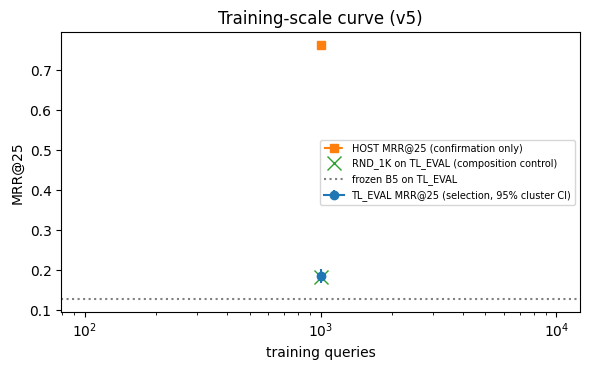

PROVISIONAL (not every TL scale model trained yet) spectrum model -> C:\Users\myben\OneDrive\Documents\Enveda\outputs\v5\freeze\spectrum_model.json


In [12]:
sel_dir = D['models'] / SELECTED
sel_meta = json.loads((sel_dir / 'model_meta.json').read_text(encoding='utf-8'))
man = MODEL_MANIFEST[SELECTED]
import casmi.spectra.reference_selection as _rs
freeze = {
    'freeze_status': FREEZE_STATUS, 'stage': STAGE, 'model_id': SELECTED, 'model_dir': str(sel_dir), 'manifest': man, 'manifest_hash': MAN_META[man]['manifest_sha256'],
    'feature_names': BASE_FEATURES, 'model_hashes': {p.name: sha(p) for p in sorted(sel_dir.glob('fold_*.txt'))},
    'mirror_aware_protocol_hash': hashlib.sha256((inspect.getsource(_rs) + '|mirror_aware').encode()).hexdigest()[:16],
    'similarity_config_hash': SIM_HASH, 'evidence_fingerprint': settlement['evidence_fingerprint'],
    'lgbm_params': LGBM_PARAMS, 'seed': SEED, 'code_version': CODE_VERSION,
    'tl_eval_metrics': {**RESULTS['tl_eval'][SELECTED], 'ci': tl_ci.set_index('model').loc[SELECTED, ['ci_low', 'ci_high']].to_dict()},
    'host_confirmation_metrics': {**RESULTS['host'][SELECTED], 'ci': host_ci.set_index('model').loc[SELECTED, ['ci_low', 'ci_high']].to_dict()},
    'density_reweighted_host_estimate': {k: v for k, v in DENSITY.get(SELECTED, {}).items() if k != 'table'},
    'k_stress': stress[stress['model'] == SELECTED][['dataset', 'k', 'mrr_at_25', 'hit_at_1']].to_dict('records'),
    'scaling_status': decision['scaling_status'], 'scale_decision': decision,
    'selection_rule': V5_RULE, 'selection_rule_sha256': prereg['rule_sha256'], 'selection_lock': str(LOCK_PATH),
    'scoring': 'mean of 5 fold predictions; ties score DESC, abs_mass_error_ppm ASC, connectivity_key ASC',
    'frozen_at': pd.Timestamp.now(tz='UTC').isoformat(),
}
jdump(freeze, D['freeze'] / 'spectrum_model.json')
scale_summary = {'status': STATUS, 'n_train_queries': N_TRAIN, 'tl_eval': RESULTS['tl_eval'], 'host': RESULTS['host'],
                 'oof_diagnostic': RESULTS['oof'], 'scale_decision': decision, 'selected': SELECTED,
                 'density_reweighted': {m: {k: v for k, v in d.items() if k != 'table'} for m, d in DENSITY.items()}}
jdump(scale_summary, D['root'] / 'scale_summary.json')

fig, ax = plt.subplots(figsize=(6, 3.8))
pts = [m for m in ('V1_TL_1K', 'V1_TL_3K', 'V1_TL_10K') if STATUS.get(m) == 'OK']
xs = [N_TRAIN[m] for m in pts]
ci = tl_ci.set_index('model')
ax.errorbar(xs, [RESULTS['tl_eval'][m]['mrr_at_25'] for m in pts],
            yerr=[[RESULTS['tl_eval'][m]['mrr_at_25'] - ci.loc[m, 'ci_low'] for m in pts], [ci.loc[m, 'ci_high'] - RESULTS['tl_eval'][m]['mrr_at_25'] for m in pts]],
            fmt='o-', label='TL_EVAL MRR@25 (selection, 95% cluster CI)')
ax.plot(xs, [RESULTS['host'][m]['mrr_at_25'] for m in pts], 's--', label='HOST MRR@25 (confirmation only)')
if 'V1_RND_1K' in RESULTS['tl_eval']:
    ax.plot([N_TRAIN['V1_RND_1K']], [RESULTS['tl_eval']['V1_RND_1K']['mrr_at_25']], 'x', ms=10, label='RND_1K on TL_EVAL (composition control)')
ax.axhline(RESULTS['tl_eval']['B5_frozen_v4b']['mrr_at_25'], color='grey', ls=':', label='frozen B5 on TL_EVAL')
ax.set_xscale('log'); ax.set_xlabel('training queries'); ax.set_ylabel('MRR@25'); ax.legend(fontsize=7); ax.set_title('Training-scale curve (v5)')
fig.tight_layout(); fig.savefig(D['figures'] / 'scale_curve_v5.png', dpi=130); plt.show()
print(FREEZE_STATUS, 'spectrum model ->', D['freeze'] / 'spectrum_model.json')